<a href="https://colab.research.google.com/github/rileyrichmond18/is_4487_classresources/blob/main/assignment_10_RichmondRiley.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS4487 Week 10 - Assignment

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data
3. Fit a model
4. Test the accuracy of the model
6.  Use the model to predict on a new dataset (without the target)

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Case: AdviseInvest
You work on a small team of data analysts at AdviseInvest, a venture-backed startup. The Director of Sales at AdviseInvest has approached your team asking for help solving a staffing problem.

### The Company
The company's mission is to provide tools and support to help ordinary people gain control of their personal finances. The company leverages technology to provide affordable financial advice to a national client base.

Customers who reach AdviseInvest's website go through five steps:

- Open an account.
- Complete a customer profile form with basic information about their background and finances.
- Schedule a free phone conversation with a sales representative during a 1-hour window of time.
- Attend the free phone conversation.
- Buy a financial plan.
- There are three types of financial plans: Beginner, Intermediate, and Advanced. Each is sold at a different price, and there are varying degrees of personalization. After a customer purchases a financial plan, the customer is assigned a financial planner who helps determine the customer's goals and advises the customer on spending decisions.

### The Problem
Some customers are lost at each stage of the process. Steps 3 and 4 are particularly challenging because approximately 50% of those who schedule a phone conversation fail to pick up the call. This leads to inefficiencies from a staffing perspective.

AdviseInvest has 4 sales reps on staff during each particular 1-hour window. Each of the 4 reps is assigned 2 prospective customers per hour, which means that the company schedules a total of 8 phone calls per hour. The calls are outgoing: sales reps call customers who scheduled a phone conversation during that hour window.

Unfortunately, as noted above, many of the customers who scheduled a call do not answer. As a consequence, sales reps are often left underutilized. Moreover, they are underutilized unevenly. For example, it is possible that one sales rep will not do any sales calls during that hour, whereas another will be busy the entire hour with two calls. Sales reps have nothing to do when customers do not answer the scheduled phone call.

### AdviseInvest Data Dictionary


| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| customer_id | Unique customer identifier | Numeric | |
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |

### Load Libraries

Import the libraries you will need, such as:
- Pandas
- Sklearn
- Matplotlib


In [1]:
#Import libraries  🔧

import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import numpy as np

## Step 1: Initial Data Understanding

### Do the following:
 - Import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to the DataSets folder and look for `adviseinvest_historical_data.csv`)
 - Describe or profile the dataframe
 - Look for any outliers, missing values, or duplicates

In [2]:
#Import the data 🔧

url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/adviseinvest_historical_data.csv"

df = pd.read_csv(url)

In [3]:
#View the datatypes 🔧

print("First 5 rows:")
print(df.head())

print("\nDataframe shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)


First 5 rows:
   customer_id  answered  income female  age  job  num_dependents  rent  \
0        10098         0  -65600      0   24    2               1     0   
1          184         0    4330      0   24    2               2     1   
2          194         0    4330      0   22    2               1     1   
3          689         0    4330      0   24    2               2     1   
4          811         0    4330      0   22    2               1     1   

   own_res  new_car  chk_acct  sav_acct  num_accts  mobile  product  
0        1      1.0         1         1          3       0        0  
1        0      0.0         1         3          1       0        0  
2        0      0.0         3         0          0       0        0  
3        0      0.0         1         3          1       0        0  
4        0      0.0         3         0          0       0        0  

Dataframe shape:
(29504, 15)

Column names:
Index(['customer_id', 'answered', 'income', 'female', 'age', 'job',
  


Summary statistics (numeric):
        customer_id      answered         income           age           job  \
count  29504.000000  29504.000000   29504.000000  29504.000000  29504.000000   
mean   14850.475563      0.546638   33766.893303     34.773454      1.915401   
std     8517.254310      0.497829   29379.202710     11.369865      0.658183   
min       99.000000      0.000000  -65600.000000     19.000000      0.000000   
25%     7474.750000      0.000000   13550.000000     26.000000      2.000000   
50%    14850.500000      1.000000   23310.000000     32.000000      2.000000   
75%    22226.250000      1.000000   41690.000000     40.000000      2.000000   
max    29602.000000      1.000000  159450.000000    132.000000      3.000000   

       num_dependents          rent       own_res       new_car      chk_acct  \
count    29504.000000  29504.000000  29504.000000  29502.000000  29504.000000   
mean         1.140998      0.210412      0.681128      0.240797      1.468547   
std  

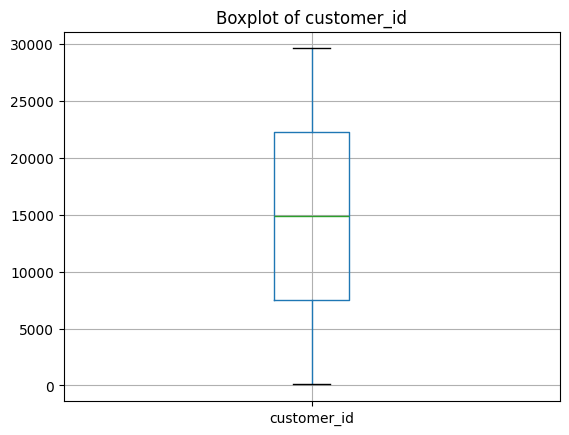

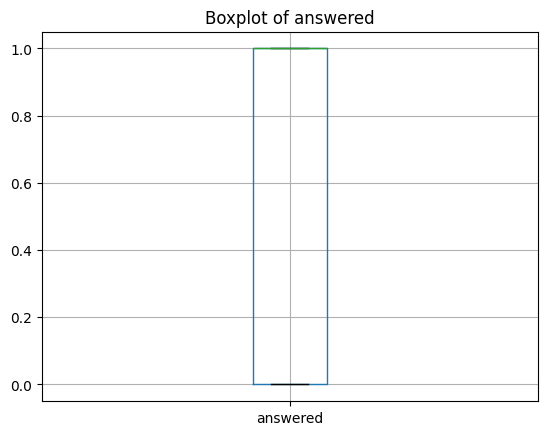

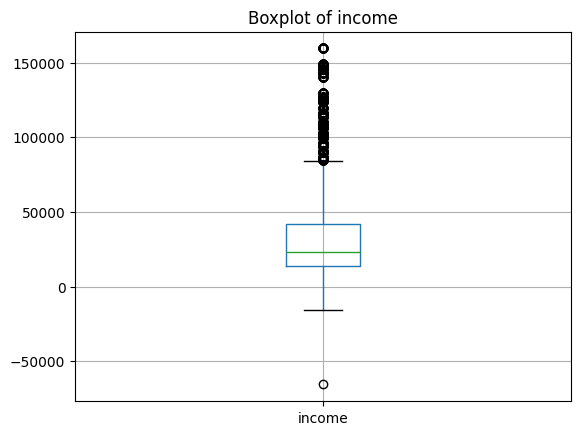

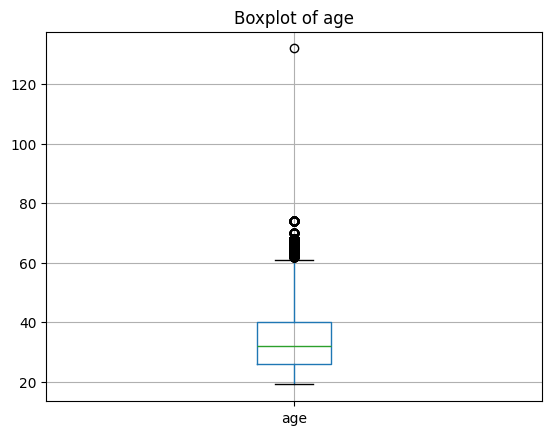

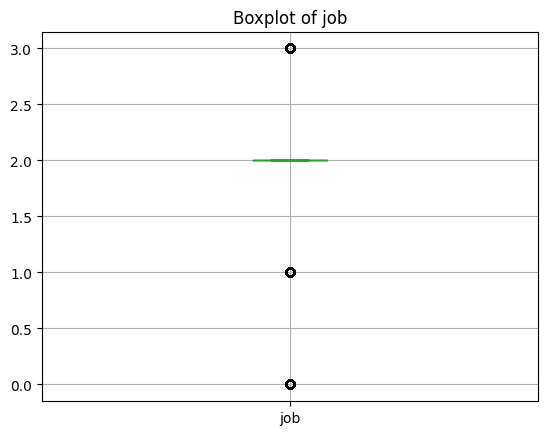

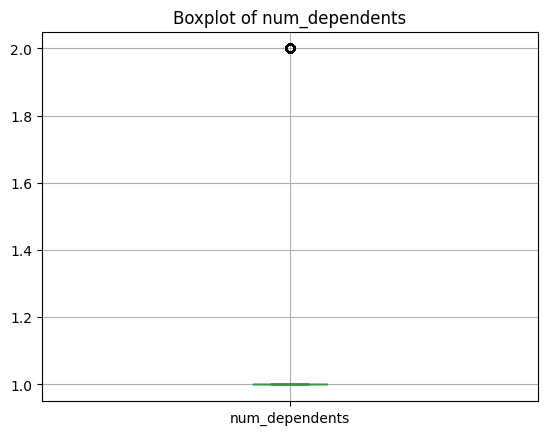

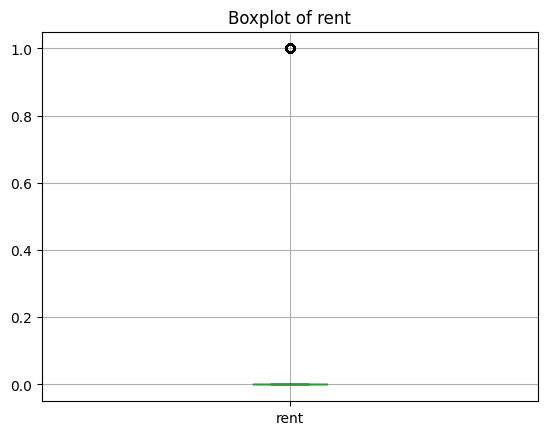

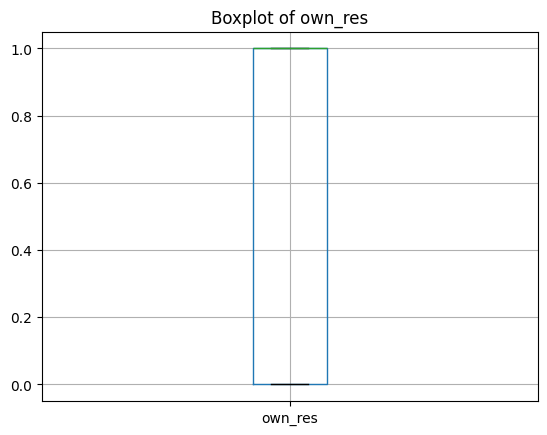

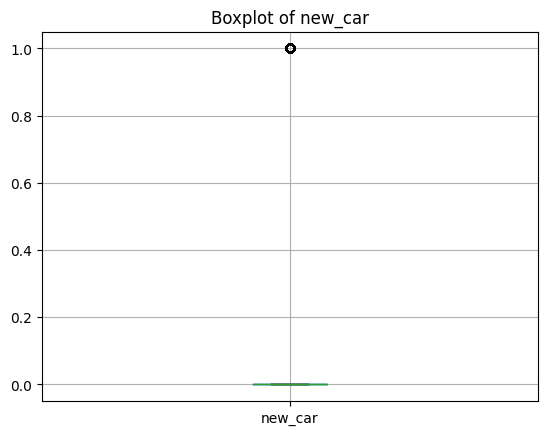

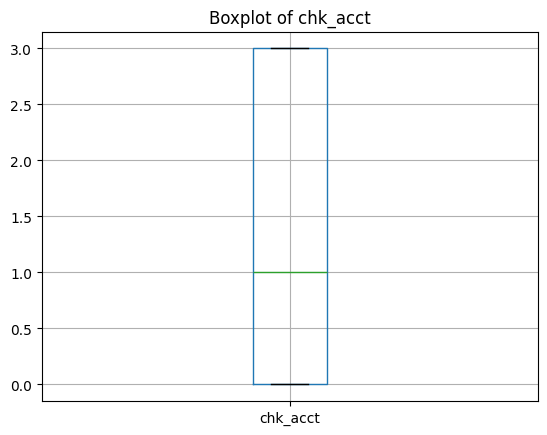

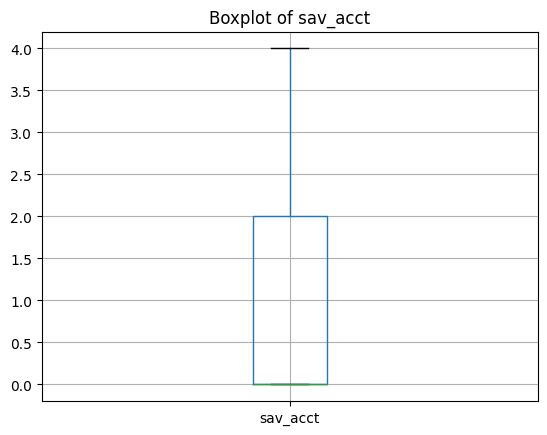

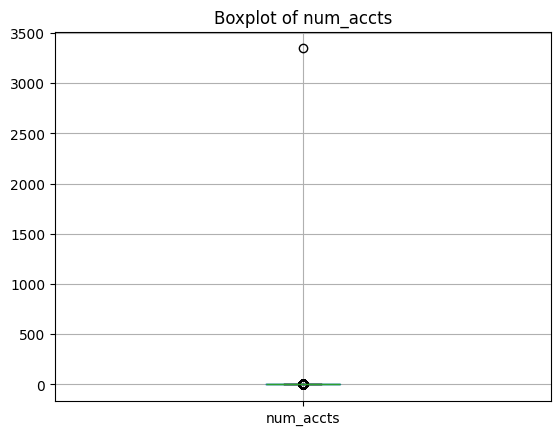

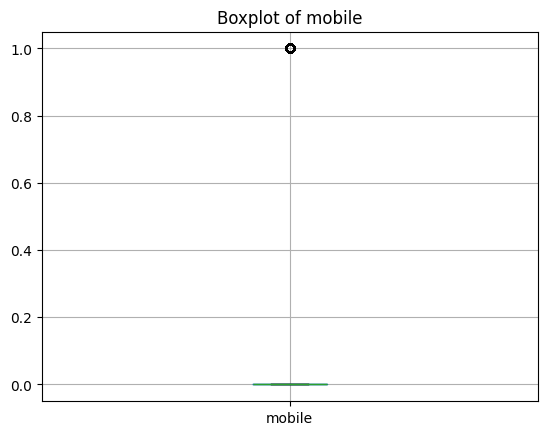

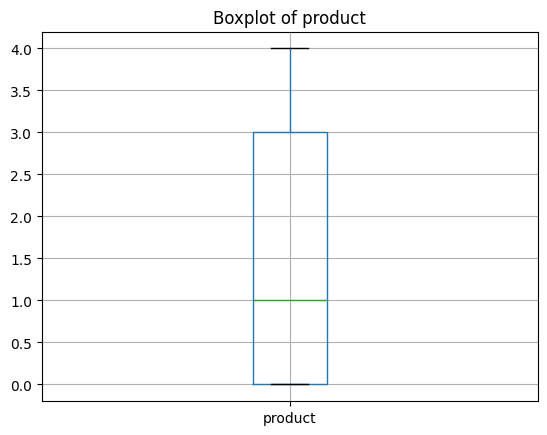

In [4]:
#Describe the data 🔧

print("\nSummary statistics (numeric):")
print(df.describe())

print("\nSummary statistics (including categorical):")
print(df.describe(include='all'))

print("\nMissing values per column:")
print(df.isnull().sum())

duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure()
    df.boxplot(column=col)
    plt.title(f'Boxplot of {col}')
    plt.show()

## Step 2: Data Preparation

### 2.1: Data Cleanup
- Check for and remove any outliers
- Consider fixing any missing data (should you delete the record or impute the value?)
- Clean up the data and put it in a new dataframe named "df_clean"


In [5]:
#delete outliers 🔧
df_clean = df.copy()

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower_bound) &
        (df_clean[col] <= upper_bound)
    ]


In [6]:
#cleanup any missing or non-standardized data 🔧

#numeric columns fill with median
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

#categorical columns fill with mode
categorical_cols = df_clean.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

#check
print("Cleaned dataframe shape:", df_clean.shape)

print("\nRemaining missing values:")
print(df_clean.isnull().sum())

print("\nPreview of cleaned data:")
print(df_clean.head())

Cleaned dataframe shape: (6592, 15)

Remaining missing values:
customer_id       0
answered          0
income            0
female            0
age               0
job               0
num_dependents    0
rent              0
own_res           0
new_car           0
chk_acct          0
sav_acct          0
num_accts         0
mobile            0
product           0
dtype: int64

Preview of cleaned data:
     customer_id  answered  income female  age  job  num_dependents  rent  \
257          463         0    6390      0   30    2               1     0   
258         1565         0    6390      0   30    2               1     0   
259         1766         0    6390      0   30    2               1     0   
260         2267         0    6390      0   30    2               1     0   
261         2394         0    6390      0   30    2               1     0   

     own_res  new_car  chk_acct  sav_acct  num_accts  mobile  product  
257        1      0.0         1         0          2       0   

### 2.2: Standardize variables

 - Change "answered" to a boolean (true/false) type
 - Convert any variables that should be an integer into an integer

In [8]:
# Convert answered to boolean 🔧

df_clean["answered"] = df_clean["answered"].astype(bool)


In [10]:
# Convert variables to integer data type 🔧

if "female" in df_clean.columns:
    df_clean["female"] = df_clean["female"].replace({
        "F": 0,
        "M": 1,
        "f": 0,
        "m": 1,
        "Female": 0,
        "Male": 1,
        "female": 0,
        "male": 1
    })

int_columns = [
    "customer_id",
    "income",
    "female",
    "age",
    "job",
    "num_dependents",
    "rent",
    "own_res",
    "new_car",
    "chk_acct",
    "sav_acct",
    "num_accts",
    "mobile",
    "product"
]

#keep only existing columns
int_columns = [col for col in int_columns if col in df_clean.columns]

#convert
for col in int_columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")
    df_clean[col] = df_clean[col].fillna(0).astype(int)

#check
print(df_clean.dtypes)
print(df_clean.head())

customer_id       int64
answered           bool
income            int64
female            int64
age               int64
job               int64
num_dependents    int64
rent              int64
own_res           int64
new_car           int64
chk_acct          int64
sav_acct          int64
num_accts         int64
mobile            int64
product           int64
dtype: object
     customer_id  answered  income  female  age  job  num_dependents  rent  \
257          463     False    6390       0   30    2               1     0   
258         1565     False    6390       0   30    2               1     0   
259         1766     False    6390       0   30    2               1     0   
260         2267     False    6390       0   30    2               1     0   
261         2394     False    6390       0   30    2               1     0   

     own_res  new_car  chk_acct  sav_acct  num_accts  mobile  product  
257        1        0         1         0          2       0        0  
258        1 

### 2.3 Convert variables to categorical

- Find at least 8 variables that would be appropriate to convert to categories

In [11]:
#Convert categorical variables 🔧

categorical_cols = [
    "female",
    "job",
    "rent",
    "own_res",
    "new_car",
    "chk_acct",
    "sav_acct",
    "mobile",
    "product"
]

#keep only existing columns
categorical_cols = [col for col in categorical_cols if col in df_clean.columns]

#convert
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype("category")

#check
print(df_clean.dtypes)
print(df_clean[categorical_cols].head())

customer_id          int64
answered              bool
income               int64
female            category
age                  int64
job               category
num_dependents       int64
rent              category
own_res           category
new_car           category
chk_acct          category
sav_acct          category
num_accts            int64
mobile            category
product           category
dtype: object
    female job rent own_res new_car chk_acct sav_acct mobile product
257      0   2    0       1       0        1        0      0       0
258      0   2    0       1       0        1        0      0       0
259      0   2    0       1       0        1        0      0       0
260      0   2    0       1       0        1        0      0       0
261      0   2    0       1       0        1        0      0       0


# Step 3: Exploratory Data Analysis (EDA)

### Do the following:
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted



In [12]:
#plot settings

plt.rcParams["figure.figsize"] = (8, 5)

#check target distribution

print(df_clean["answered"].value_counts())
print(df_clean["answered"].value_counts(normalize=True))

answered
True     3904
False    2688
Name: count, dtype: int64
answered
True     0.592233
False    0.407767
Name: proportion, dtype: float64


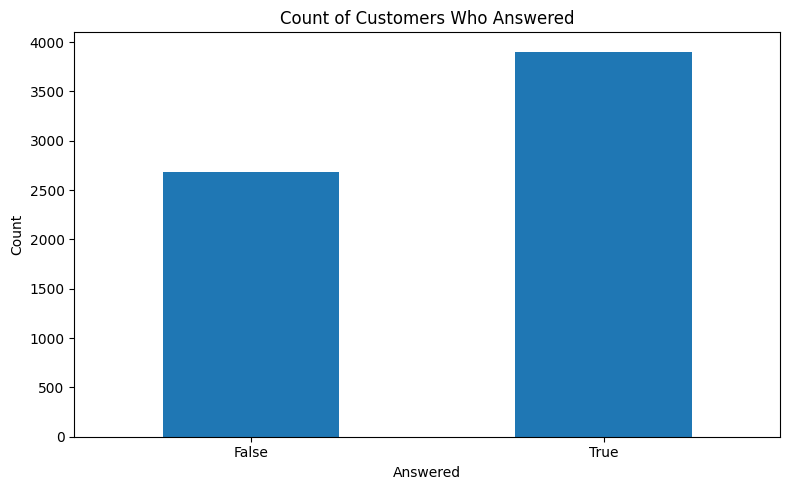

In [13]:
# Chart 1 🔧 bar chart, answered count

answered_counts = df_clean["answered"].value_counts().sort_index()

plt.figure()
answered_counts.plot(kind="bar")
plt.title("Count of Customers Who Answered")
plt.xlabel("Answered")
plt.ylabel("Count")
plt.xticks([0, 1], ["False", "True"], rotation=0)
plt.tight_layout()
plt.show()

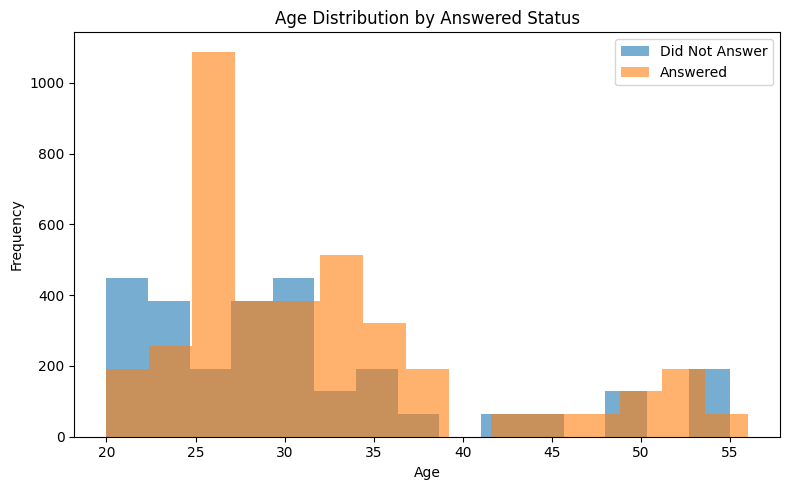

In [14]:
# Chart 2 🔧 histogram, age by answered

plt.figure()
plt.hist(df_clean[df_clean["answered"] == False]["age"], bins=15, alpha=0.6, label="Did Not Answer")
plt.hist(df_clean[df_clean["answered"] == True]["age"], bins=15, alpha=0.6, label="Answered")
plt.title("Age Distribution by Answered Status")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

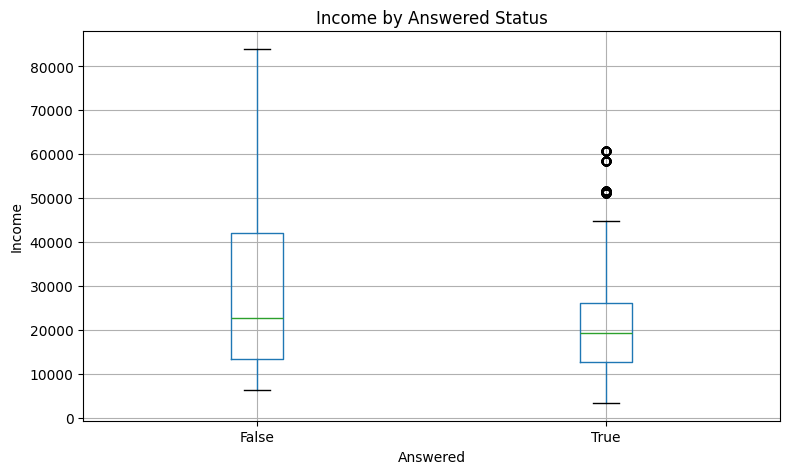

In [15]:
# Chart 3 🔧 boxplot, income by answered

plt.figure()
df_clean.boxplot(column="income", by="answered")
plt.title("Income by Answered Status")
plt.suptitle("")  # removes automatic pandas subtitle
plt.xlabel("Answered")
plt.ylabel("Income")
plt.xticks([1, 2], ["False", "True"])
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

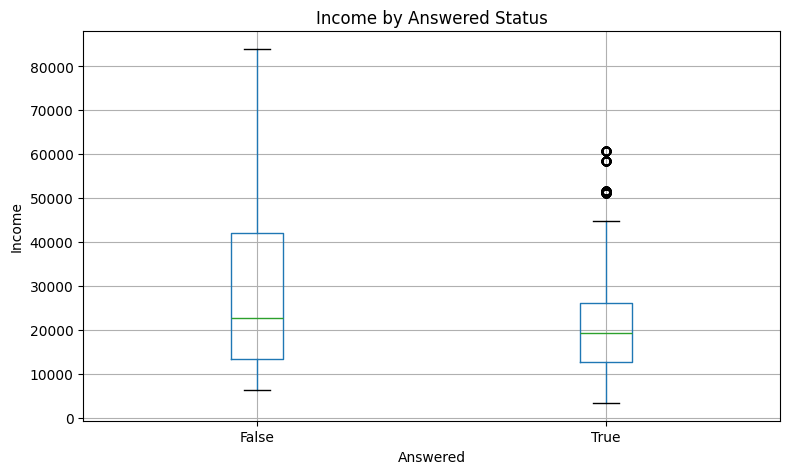

In [16]:
# Chart 4 🔧 bar chart, answer rate by job

plt.figure()
df_clean.boxplot(column="income", by="answered")
plt.title("Income by Answered Status")
plt.suptitle("")  # removes automatic pandas subtitle
plt.xlabel("Answered")
plt.ylabel("Income")
plt.xticks([1, 2], ["False", "True"])
plt.tight_layout()
plt.show()

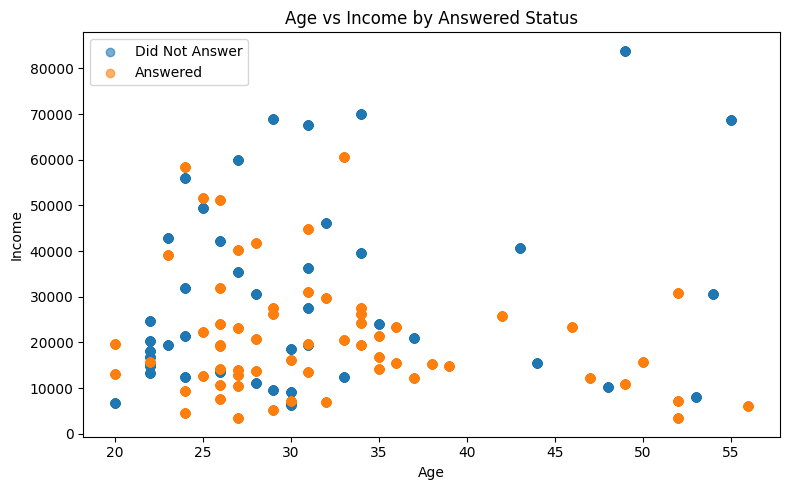

In [36]:
# Chart 5 🔧 scatter plot, age vs income

plt.figure()
answered_false = df_clean[df_clean["answered"] == False]
answered_true = df_clean[df_clean["answered"] == True]

plt.scatter(answered_false["age"], answered_false["income"], alpha=0.6, label="Did Not Answer")
plt.scatter(answered_true["age"], answered_true["income"], alpha=0.6, label="Answered")

plt.title("Age vs Income by Answered Status")
plt.xlabel("Age")
plt.ylabel("Income")
plt.legend()
plt.tight_layout()
plt.show()

## Step 4: Modeling

### 4.1: Calculate the base probability of answering

If we use no model at all, how good is our chance of predicting someone leaving?  Use a calculation to find the chances of someone leaving.

In [18]:
#get the default probability 🔧

base_probability = df_clean["answered"].mean()

print("Base probability of answering:", base_probability)
print("Base probability of answering (%):", round(base_probability * 100, 2), "%")

Base probability of answering: 0.5922330097087378
Base probability of answering (%): 59.22 %


### 4.2: Split the training and testing datasets

- split df_clean using train_test_split function
- all variables except answered should be in the x variable
- answered is in the y variable


In [19]:
# Split data into training and testing sets 🔧

#x are independent variables
X = df_clean.drop(columns=["answered"])

#y is target variable
y = df_clean["answered"]

#split
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#check
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5273, 14)
X_test shape: (1319, 14)
y_train shape: (5273,)
y_test shape: (1319,)


### 4.3: Create a Decision Tree
- Use all available attributes (except those that were eliminated in step 3)
- It is recommended to use the type "entropy" and a max_depth of 4

In [22]:
#create a tree  🔧

#remove leakage variables
X = df_clean.drop(columns=["answered", "product"])

y = df_clean["answered"]

#split
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#create tree
tree_model = sklearn.tree.DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

#fit model
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

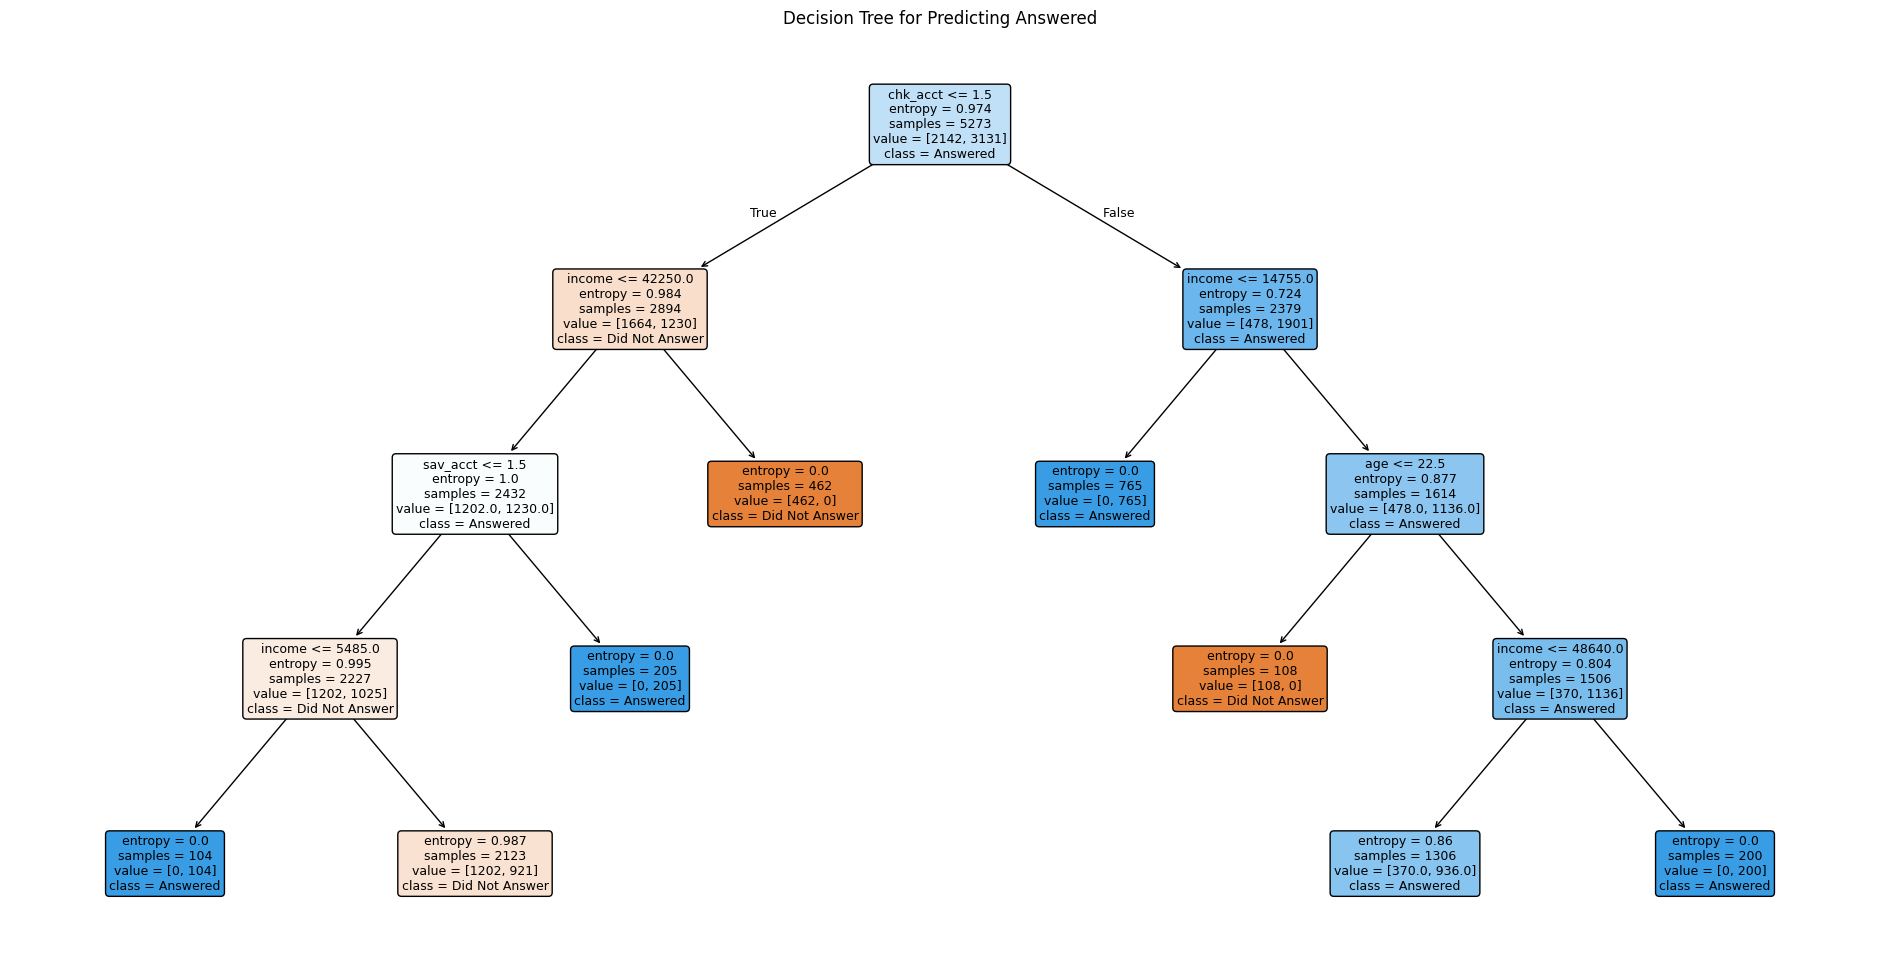

In [23]:
#display (visualize) the tree 🔧

plt.figure(figsize=(24, 12))
sklearn.tree.plot_tree(
    tree_model,
    feature_names=X_train.columns,
    class_names=["Did Not Answer", "Answered"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree for Predicting Answered")
plt.show()

### 4.4: What is the accuracy?

This should be better than the base probability, or you have failed in your objective

In [24]:
#calculate the probability for your tree 🔧

#predict on test set
y_pred = tree_model.predict(X_test)

#model accuracy
tree_accuracy = sklearn.metrics.accuracy_score(y_test, y_pred)

#baseline accuracy
baseline_accuracy = max(df_clean["answered"].mean(), 1 - df_clean["answered"].mean())

print("Decision Tree Accuracy:", round(tree_accuracy, 4))
print("Decision Tree Accuracy (%):", round(tree_accuracy * 100, 2), "%")
print("Baseline Accuracy:", round(baseline_accuracy, 4))
print("Baseline Accuracy (%):", round(baseline_accuracy * 100, 2), "%")

if tree_accuracy > baseline_accuracy:
    print("The decision tree performed better than the baseline.")
else:
    print("The decision tree did NOT perform better than the baseline.")

Decision Tree Accuracy: 0.7657
Decision Tree Accuracy (%): 76.57 %
Baseline Accuracy: 0.5922
Baseline Accuracy (%): 59.22 %
The decision tree performed better than the baseline.


### 4.5: Create a confusion matrix

This will show false positives, true positives, etc.

In [27]:
#create a basic confusion matrix 🔧

#predict on test set
y_pred = tree_model.predict(X_test)

#create confusion matrix
cm = sklearn.metrics.confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[468  78]
 [231 542]]


Create a more visual, interpretable version of the matrix

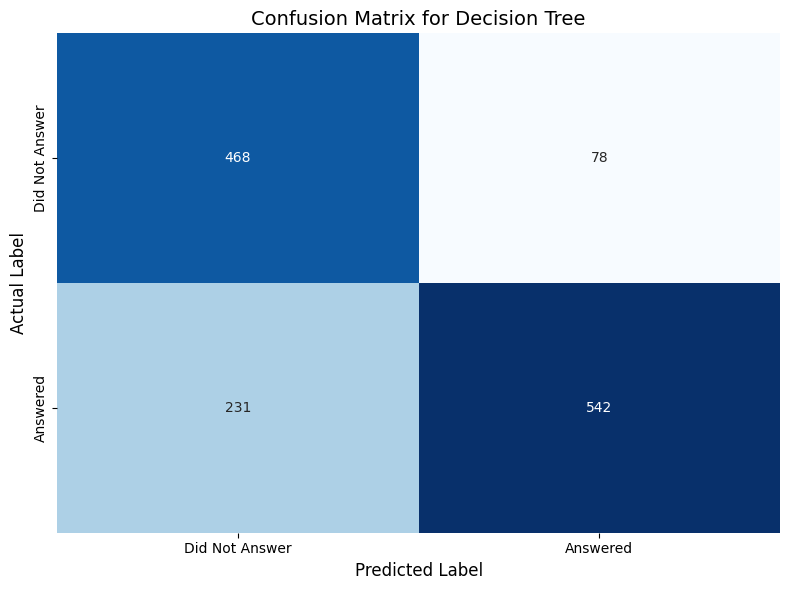

True Negatives: 468
False Positives: 78
False Negatives: 231
True Positives: 542


In [26]:
#Create a beautiful matrix; hint - try using Seaborn Heatmap 🔧

import seaborn as sns

#heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Did Not Answer", "Answered"],
    yticklabels=["Did Not Answer", "Answered"]
)

plt.title("Confusion Matrix for Decision Tree", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.tight_layout()
plt.show()

#print each value
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

# Step 5: Evaluate the Model

**Assumptions**

One of the simplifying assumptions we will make in this project is that all the customers who answer the phone will purchase a product. (This assumption is actually verified by the data.) To model "answered" in this case is therefore equivalent to modeling "purchased."

There are costs and benefits in this case. We will assume that customers purchase a product for 100 dollars. This was the average cost of AdviseInvest products, according to the Director of Sales.  Also, as we learned in the interview, the agent time to make the sale is worth 25 dollars. Profit would therefore be \$75 dollars for an answered call and a purchase. In sum:

**Benefit**: True positive. The customer is predicted to answer, does answer, and purchases a product for 100 dollars for a profit of 100 - 25 = 75.

**Cost**: False positive. The customer is predicted to answer, but does not answer, so there is a loss of 25. (We assume the agent cannot schedule another call at the last minute, or spends the entire time slot trying to make the call.)

When you create a calculation you can use:
- True answered * 75 -> These people purchased
- False answered * 25 -> You can't schedule another call

For this exercise, we propose that customers who are not predicted to answer will not be called, so there would be no benefits and no costs for them.  

### 5.1 Calculate the Profit Using the Model

In [28]:
# Write a calcuation for the profit from your model 🔧

#predict on the test set
y_pred = tree_model.predict(X_test)

#build confusion matrix values
cm = sklearn.metrics.confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

#profit calculations
profit = (tp * 75) - (fp * 25)

print("True Positives:", tp)
print("False Positives:", fp)
print("Profit from model: $", profit)

True Positives: 542
False Positives: 78
Profit from model: $ 38700


### 5.2 Compare to the Default Profit

How much profit (revenue - costs) could be expected if all customers are called? We can consider this a baseline case for profit since it does not require a model.

In other words, to calculate profit in this baseline scenario treat the customers who answer as true positives treat the customers who do not answer as false positives.

In [29]:
#Write a calculation for the overall profit without using the model (default) 🔧

#baseline profit on the test set
tp_default = (y_test == True).sum()
fp_default = (y_test == False).sum()

default_profit = (tp_default * 75) - (fp_default * 25)

print("Answered customers in test set:", tp_default)
print("Did not answer customers in test set:", fp_default)
print("Default profit without model (test set): $", default_profit)

Answered customers in test set: 773
Did not answer customers in test set: 546
Default profit without model (test set): $ 44325


### 5.3 Tune the Model
- Adjust the size or shape of the tree, then test the accuracy
- Keep changing these parameters until you end up with a tree with accuracy that is better than the initial model

Initial Accuracy: 0.7657
Best Tuned Accuracy: 0.8832
Best Parameters: {'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 1}


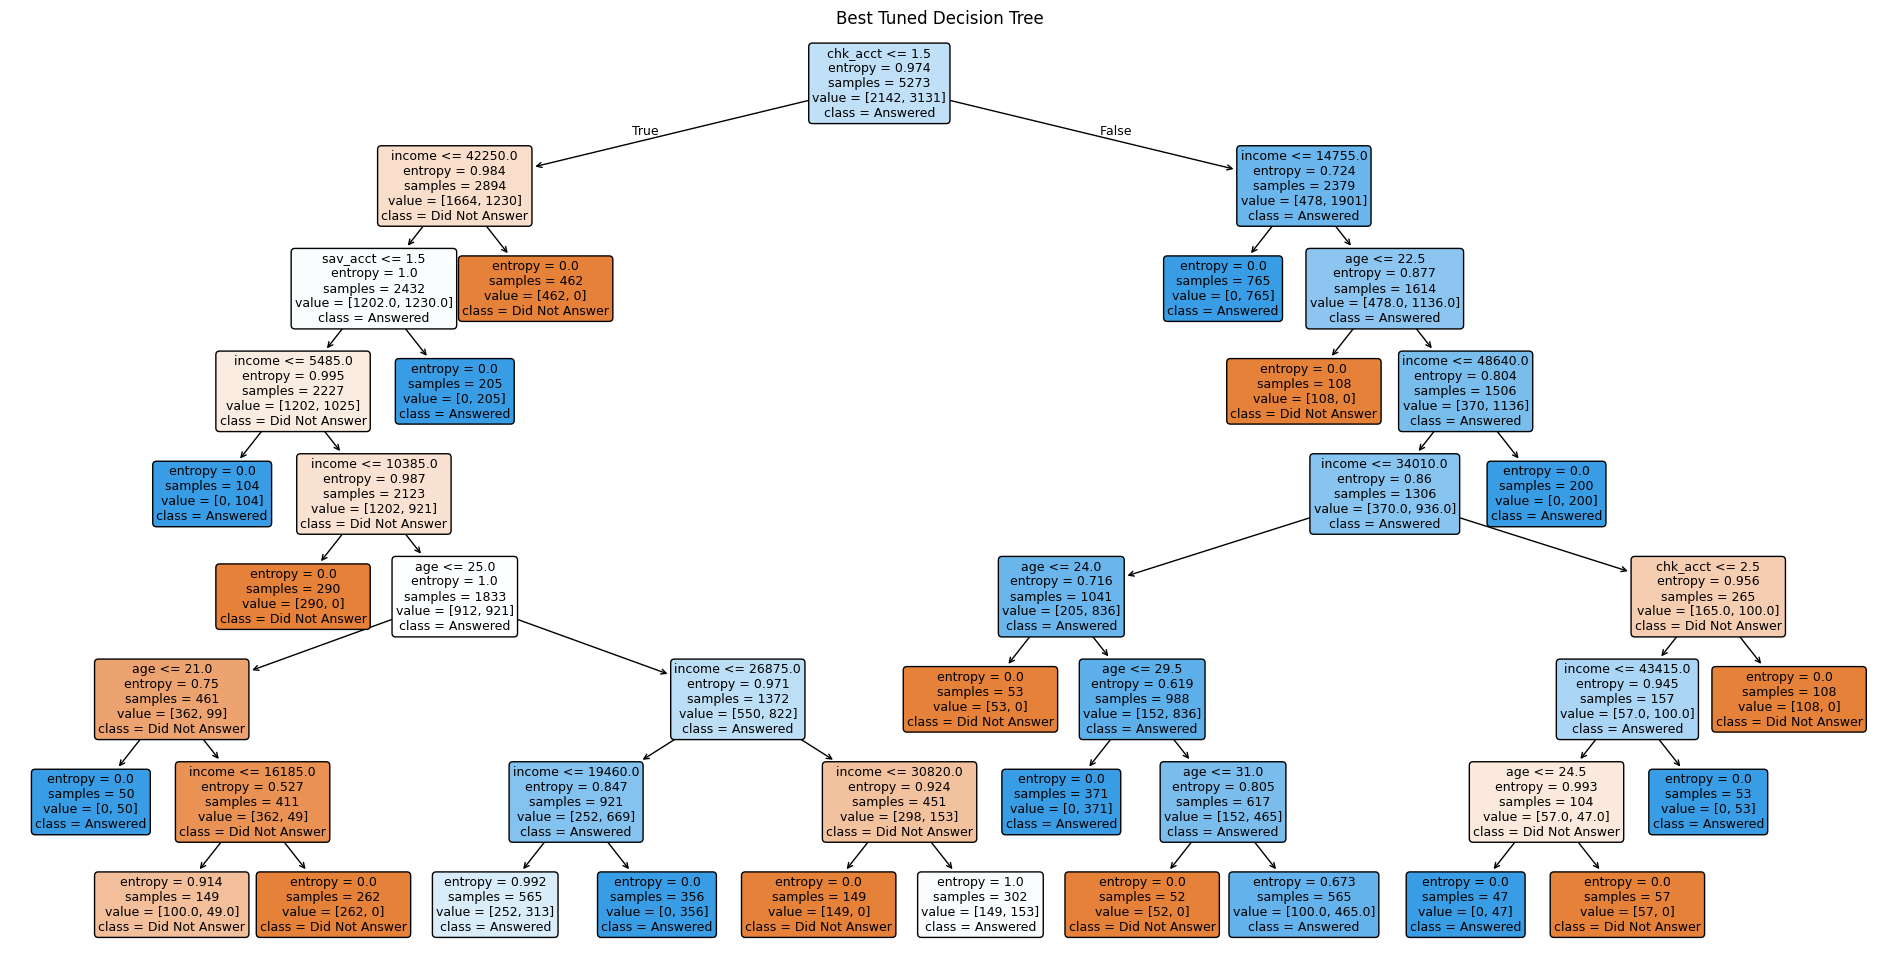

In [31]:
# Create a new version of the tree with new parameters 🔧

#calculate initial model accuracy
y_pred_initial = tree_model.predict(X_test)
initial_accuracy = sklearn.metrics.accuracy_score(y_test, y_pred_initial)

#try multiple parameter combinations and keep the best option
best_accuracy = initial_accuracy
best_model = tree_model
best_params = {"max_depth": 4, "min_samples_split": 2, "min_samples_leaf": 1}

for depth in [3, 4, 5, 6, 7, 8]:
    for split in [2, 5, 10, 15]:
        for leaf in [1, 2, 5, 10]:
            model = sklearn.tree.DecisionTreeClassifier(
                criterion="entropy",
                max_depth=depth,
                min_samples_split=split,
                min_samples_leaf=leaf,
                random_state=42
            )

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            accuracy = sklearn.metrics.accuracy_score(y_test, y_pred)

            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_model = model
                best_params = {
                    "max_depth": depth,
                    "min_samples_split": split,
                    "min_samples_leaf": leaf
                }

print("Initial Accuracy:", round(initial_accuracy, 4))
print("Best Tuned Accuracy:", round(best_accuracy, 4))
print("Best Parameters:", best_params)

#visualize best model
plt.figure(figsize=(24, 12))
sklearn.tree.plot_tree(
    best_model,
    feature_names=X_train.columns,
    class_names=["Did Not Answer", "Answered"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Best Tuned Decision Tree")
plt.show()

In [32]:
# Calculate a new probability 🔧

y_pred_tuned = best_model.predict(X_test)
new_accuracy = sklearn.metrics.accuracy_score(y_test, y_pred_tuned)

print("New Tuned Accuracy:", round(new_accuracy, 4))
print("New Tuned Accuracy (%):", round(new_accuracy * 100, 2), "%")


New Tuned Accuracy: 0.8832
New Tuned Accuracy (%): 88.32 %


### 5.4 Apply the Model to New Customers
- Import the "adviseinvest_new_customer_data.csv" file
- Using the tree model, predict each customer for the target variable  by feeding the new customer data into the model

In [33]:
#Import new customer data into a new data frame 🔧

# Load new customer data from GitHub RAW URL
new_data_url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/adviseinvest_new_customer_data.csv"
df_new = pd.read_csv(new_data_url)

In [34]:
#Predict the number of customers who will be yes/no for the target variable 🔧

#clean column names
df_new.columns = df_new.columns.str.strip()

#fix text values before converting
if "female" in df_new.columns:
    df_new["female"] = df_new["female"].replace({
        "F": 0, "M": 1,
        "f": 0, "m": 1,
        "Female": 0, "Male": 1,
        "female": 0, "male": 1
    })

#convert integer columns
int_columns = [
    "customer_id",
    "income",
    "female",
    "age",
    "job",
    "num_dependents",
    "rent",
    "own_res",
    "new_car",
    "chk_acct",
    "sav_acct",
    "num_accts",
    "mobile"
]

int_columns = [col for col in int_columns if col in df_new.columns]

for col in int_columns:
    df_new[col] = pd.to_numeric(df_new[col], errors="coerce").fillna(0).astype(int)

#convert categorical columns to category
categorical_cols = [
    "female",
    "job",
    "rent",
    "own_res",
    "new_car",
    "chk_acct",
    "sav_acct",
    "mobile"
]

categorical_cols = [col for col in categorical_cols if col in df_new.columns]

for col in categorical_cols:
    df_new[col] = df_new[col].astype("category")

#keep only the columns used by the trained model
df_new_model = df_new[X_train.columns]

#predict answered / not answered
new_predictions = best_model.predict(df_new_model)

#predicted probabilities
new_probabilities = best_model.predict_proba(df_new_model)[:, 1]

#add predictions back to dataframe
df_new["predicted_answered"] = new_predictions
df_new["predicted_probability_answered"] = new_probabilities

#results
print(df_new[["customer_id", "predicted_answered", "predicted_probability_answered"]].head())
print(df_new)

   customer_id  predicted_answered  predicted_probability_answered
0            0               False                        0.000000
1            0               False                        0.000000
2            0                True                        0.553982
3            0                True                        0.553982
4            0               False                        0.000000
     income female  age job  num_dependents rent own_res new_car chk_acct  \
0     30010      0   40   2               1    1       0       0        1   
1     30510      0   54   2               1    0       1       0        0   
2     12880      0   48   2               2    0       1       0        0   
3     15530      0   44   2               1    0       1       0        0   
4     46230      0   40   3               1    0       1       0        3   
..      ...    ...  ...  ..             ...  ...     ...     ...      ...   
995   31610      0   31   2               1    1       0   

# Step 6: Conclusion
### 6.1: Did we improve our profit using the model?  

Write your conclusion notes below:  🔧

The model-based strategy was compared with the default strategy of calling every customer. The results show that the model profit is lower than the default strategy, so the default strategy is a more profitable approach.

### 6.2: How could the model be utilized by the business?

Write your recommendations below:  🔧

AdviseInvest could integrate the model into its scheduling process so that each new customer is assigned a predicted probability of answering. Sales reps could then prioritize the customers with the highest scores. This would help the company improve rep utilization, lower the cost of missed calls, and increase profit. The model could also support better forecasting of call volume and staffing needs over time.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [37]:
!jupyter nbconvert --to html "assignment_10_RichmondRiley.ipynb"

[NbConvertApp] Converting notebook assignment_10_RichmondRiley.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 22 image(s).
[NbConvertApp] Writing 1535166 bytes to assignment_10_RichmondRiley.html
